# 🤖 Entraînement & comparaison des modèles

Ce notebook explique et illustre l'entraînement des 3 modèles
candidats sur le dataset UCI Credit Card Default.

**Plan**

1. Pourquoi cette stratégie (et les pièges à éviter)
2. Setup
3. Chargement et split train/test stratifié
4. Construction du pipeline preprocessor + SMOTE + classifier
5. GridSearchCV avec le business gain comme métrique
6. Optimisation du seuil de décision
7. Évaluation sur le test set
8. Comparaison des 3 modèles
9. SHAP : explicabilité du modèle gagnant
10. Synthèse

## 1. Stratégie — et les pièges à éviter

### Le piège classique : data leakage avec SMOTE

Tentation : faire SMOTE sur tout le dataset AVANT le split. C'est faux.
SMOTE crée des points synthétiques à partir des voisins. Si un voisin
finit dans le test set, le train set "voit" l'info de manière indirecte.
Solution : SMOTE INSIDE le pipeline, INSIDE chaque fold CV. C'est ce que
fait `imblearn.pipeline.Pipeline`.

### Pourquoi `StratifiedKFold` et `stratify=y`

Le dataset est déséquilibré (22% défauts). Sans stratification, certains
folds pourraient se retrouver avec 12% ou 35% de défauts → biais.
Stratifier garantit que chaque fold a ~22% de défauts.

### Pourquoi `business_gain` comme scoring

Accuracy = 78% en disant TOUJOURS "non-défaut". On veut maximiser un score
qui pénalise correctement les FN (5×) vs les FP (1×).

### Pourquoi optimiser le seuil ?

Par défaut, `predict()` utilise seuil 0.5 (optimal pour l'accuracy).
Pour notre coût asymétrique, l'optimum est plus bas (~0.3-0.4) : on
capture plus de défauts en acceptant plus de FP.

## 2. ⚙️ Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
FIG_DIR = ROOT / 'docs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Configure MLflow (read-only — runs already created by train.py)
mlflow.set_tracking_uri('http://localhost:5050')

## 3. Chargement et split train/test

In [2]:
from scoring.data import PROCESSED_PATH, TARGET, split_x_y

df = pd.read_parquet(PROCESSED_PATH)
print(f'Dataset processed : {df.shape}')
print(f'Taux de défaut    : {df[TARGET].mean():.3f}')
df.head(3)

Dataset processed : (30000, 36)
Taux de défaut    : 0.221


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,PAY_DELAY_COUNT,MAX_DELAY,MEAN_PAY_STATUS,HAS_EVER_DELAYED,UTIL_RATIO_1,MEAN_UTIL,MAX_UTIL,TOTAL_PAID,TOTAL_BILLED,PAY_TO_BILL_RATIO,BILL_TREND,PAY_TREND
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,2,2,-0.333333,1,0.195650,0.064200,0.195650,689.0,7704.0,0.089434,652.166667,0.000000
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,2,2,0.500000,1,0.022350,0.023718,0.028792,5000.0,17077.0,0.292791,-96.500000,-333.333333
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0,0,0.000000,0,0.324878,0.188246,0.324878,11018.0,101653.0,0.108388,2281.666667,-580.333333


In [3]:
from sklearn.model_selection import train_test_split

X, y = split_x_y(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train : {X_train.shape}  taux défaut = {y_train.mean():.3f}')
print(f'Test  : {X_test.shape}   taux défaut = {y_test.mean():.3f}')

Train : (24000, 35)  taux défaut = 0.221
Test  : (6000, 35)   taux défaut = 0.221


## 4. Construction du pipeline

Le pipeline est `preprocessor → SMOTE → classifier`. Crucial : on utilise
`imblearn.pipeline.Pipeline` (et **pas** `sklearn.pipeline.Pipeline`)
car cette version sait que SMOTE ne doit s'appliquer qu'à `fit`, pas à
`predict`.

In [4]:
from scoring.preprocessing import build_preprocessor, get_feature_columns

numeric_cols, nominal_cols = get_feature_columns(df, target=TARGET)
print(f'Numeric ({len(numeric_cols)} cols) :')
print('  ', numeric_cols[:10], '...')
print(f'\nNominal ({len(nominal_cols)} cols) :')
print('  ', nominal_cols)

Numeric (32 cols) :
   ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2'] ...

Nominal (3 cols) :
   ['SEX', 'EDUCATION', 'MARRIAGE']


In [5]:
preprocessor = build_preprocessor(numeric_cols, nominal_cols)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
                                  'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1',
                                  'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                                  'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                                  'PAY_AMT5', 'PAY_AMT6', 'PAY_DELAY_COUNT',
                                  'MAX_DELAY', 'MEAN_PAY_STATUS',
                                  'HAS_EVER_DELAYED', 'UTIL_RATIO_1',
                                  'MEAN_UTIL', 'MAX_UTIL', 'TOTAL_PAID',
                                  'TOTAL_BILLED', 'PAY_TO_BILL_RATIO', ...]),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['SEX', 'EDUCATION', 'MARRIAGE'])],
                  verbose_feature_names_out=False)

In [6]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Exemple : pipeline complet pour XGBoost
xgb_pipe = ImbPipeline([
    ('prep', build_preprocessor(numeric_cols, nominal_cols)),
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(eval_metric='logloss', random_state=42, tree_method='hist')),
])
xgb_pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6',
                                                   'PAY_DELAY_COUNT',
                                                   'MAX_DELAY',
                                                   'MEAN_PAY_STATUS',
                                                   'HAS_EVER_DELAYED...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

## 5. GridSearchCV — recherche des hyperparamètres

On utilise un **grid volontairement petit** (1 jour pour tout le projet)
mais qui couvre les hyperparamètres les plus impactants pour chaque
famille de modèle.

| Modèle | Hyperparams testés | Combinaisons |
|--------|-------------------|--------------|
| LogReg | `C` ∈ {0.1, 1, 10} | 3 |
| RandomForest | `n_estimators` × `max_depth` | 2 × 2 = 4 |
| XGBoost | `n_estimators` × `max_depth` | 2 × 2 = 4 |

Avec `StratifiedKFold(5)`, ça fait au total :
3 × 5 + 4 × 5 + 4 × 5 = **55 fits** au minimum (sans compter le refit final).

In [7]:
# Voir le code exact dans src/scoring/train.py :: get_model_specs()
# Ici juste un aperçu pour la lecture
from scoring.train import get_model_specs

for spec in get_model_specs():
    n_combos = 1
    for v in spec.param_grid.values():
        n_combos *= len(v)
    print(f'{spec.name:15s} {n_combos} combos × 5 folds = {n_combos * 5} fits')
    print(f'                params: {spec.param_grid}')

logreg          3 combos × 5 folds = 15 fits
                params: {'clf__C': [0.1, 1.0, 10.0], 'clf__penalty': ['l2']}
random_forest   4 combos × 5 folds = 20 fits
                params: {'clf__n_estimators': [200, 400], 'clf__max_depth': [8, 16], 'clf__min_samples_leaf': [5]}
xgboost         4 combos × 5 folds = 20 fits
                params: {'clf__n_estimators': [200, 400], 'clf__max_depth': [3, 6], 'clf__learning_rate': [0.1]}


## 6. Résultats — depuis MLflow

Le training a déjà tourné via `python -m scoring.train`. Récupérons
les runs depuis MLflow et comparons.

In [8]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name('credit-scoring')
runs = client.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=['metrics.test_business_gain DESC'],
)

records = []
for r in runs:
    metrics = r.data.metrics
    params = r.data.params
    name = r.data.tags.get('mlflow.runName', r.info.run_id[:8])
    records.append({
        'model': name,
        'cv_business_gain': metrics.get('cv_business_gain'),
        'cv_business_gain_std': metrics.get('cv_business_gain_std'),
        'threshold': metrics.get('optimal_threshold'),
        'test_business_gain': metrics.get('test_business_gain'),
        'test_business_cost': metrics.get('test_business_cost'),
        'test_accuracy': metrics.get('test_accuracy'),
        'test_precision': metrics.get('test_precision'),
        'test_recall': metrics.get('test_recall'),
        'test_f1': metrics.get('test_f1'),
        'test_roc_auc': metrics.get('test_roc_auc'),
    })

results_df = pd.DataFrame(records).round(3)
results_df

,model,cv_business_gain,cv_business_gain_std,threshold,test_business_gain,test_business_cost,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,xgboost,0.405,0.002,0.28,0.484,3424.0,0.645,0.357,0.756,0.485,0.771
1,random_forest,0.476,0.008,0.39,0.480,3451.0,0.669,0.372,0.724,0.492,0.775
2,logreg,0.473,0.017,0.42,0.461,3578.0,0.710,0.404,0.653,0.499,0.743


## 7. Comparaison visuelle des modèles

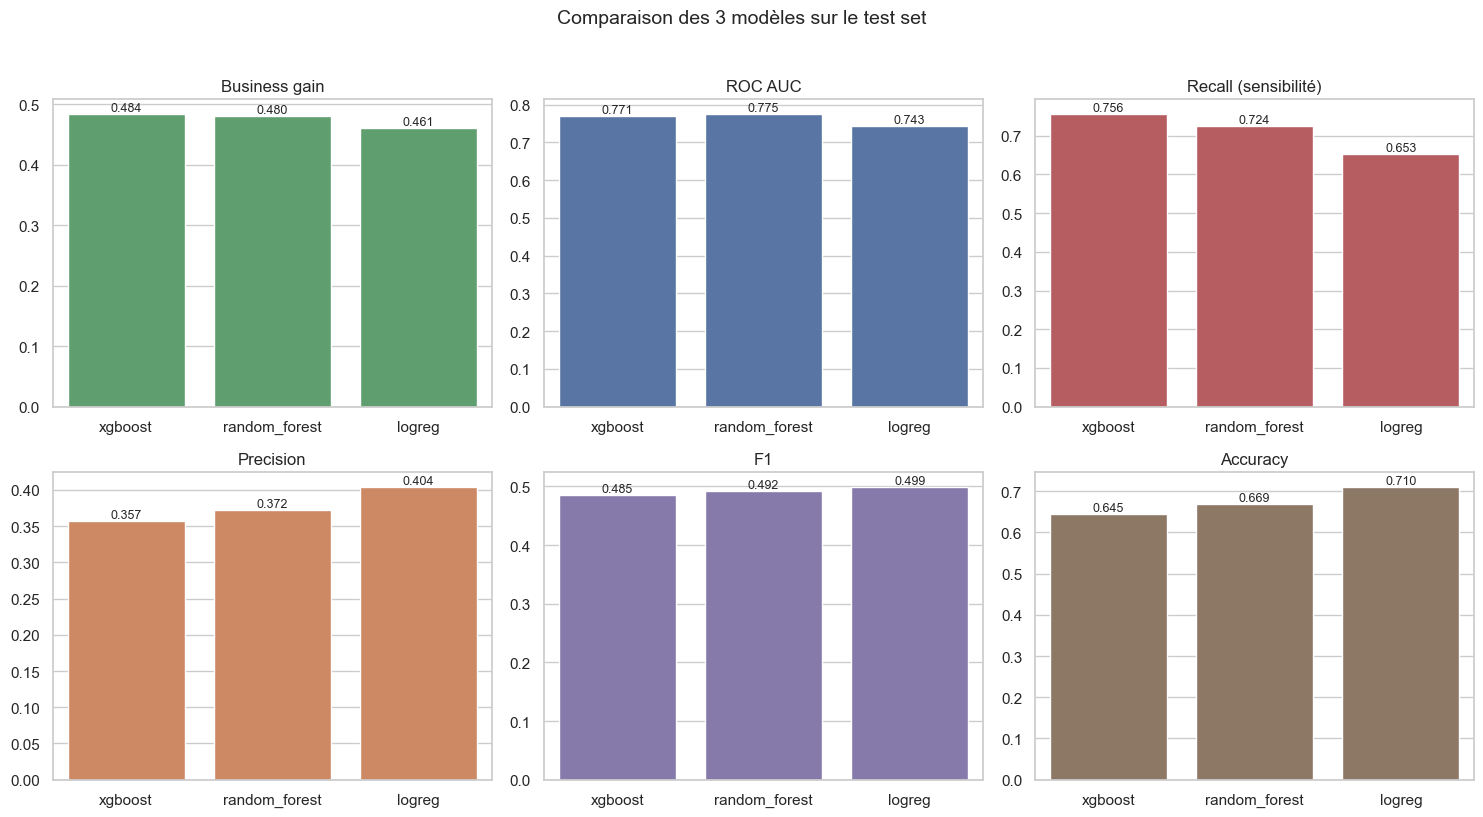

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metric_cols = [
    ('test_business_gain', 'Business gain', '#55A868'),
    ('test_roc_auc', 'ROC AUC', '#4C72B0'),
    ('test_recall', 'Recall (sensibilité)', '#C44E52'),
    ('test_precision', 'Precision', '#DD8452'),
    ('test_f1', 'F1', '#8172B2'),
    ('test_accuracy', 'Accuracy', '#937860'),
]
for ax, (col, label, color) in zip(axes.ravel(), metric_cols):
    sns.barplot(data=results_df, x='model', y=col, ax=ax, color=color)
    ax.set_title(label)
    ax.set_ylabel('')
    ax.set_xlabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Comparaison des 3 modèles sur le test set', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '21_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

**Lecture :** XGBoost gagne sur le `business_gain` (notre métrique cible)
avec le **recall le plus élevé** (75%). RandomForest a le meilleur AUC
mais un recall plus bas. LogReg reste la baseline interprétable.

Le recall élevé est crucial : il signifie qu'on **capture 75% des
défauts**, ce qui minimise les FN (les plus coûteux).

## 8. Matrices de confusion

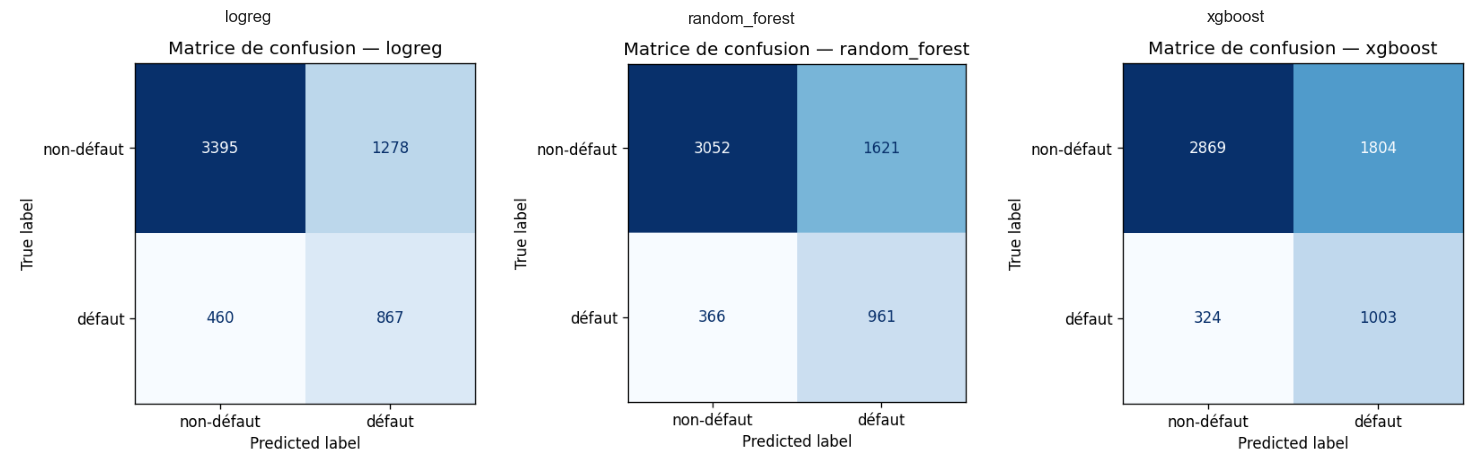

In [10]:
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, ['logreg', 'random_forest', 'xgboost']):
    img = Image.open(FIG_DIR / f'20_cm_{name}.png')
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(name)
plt.tight_layout()
plt.savefig(FIG_DIR / '21_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. 🧠 SHAP — explicabilité du modèle gagnant

SHAP (SHapley Additive exPlanations) attribue à chaque feature sa
contribution à la prédiction. C'est devenu le standard pour expliquer
les modèles à arbres comme XGBoost.

On l'utilise pour répondre à deux questions :
- **Globalement** : quelles features pèsent le plus dans les prédictions ?
- **Localement** : pour un client donné, pourquoi le modèle dit-il "défaut" ?

⚠️ SHAP est **lent**. On échantillonne 500 lignes du test set.

In [11]:
import shap

# Charger le best model (XGBoost) et son metadata
best_model = joblib.load(ROOT / 'models' / 'best_model.joblib')
metadata = json.loads((ROOT / 'models' / 'metadata.json').read_text())
print(f"Modèle chargé : {metadata['model_name']}")
print(f"Seuil optimal : {metadata['threshold']}")

Modèle chargé : xgboost
Seuil optimal : 0.28


In [12]:
# Échantillon pour SHAP (500 rows)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=500, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

# Le pipeline contient: prep -> smote -> clf
# Pour SHAP on doit appliquer prep et passer le résultat au classifier
prep = best_model.named_steps['prep']
clf = best_model.named_steps['clf']

X_transformed = prep.transform(X_sample)

# Noms des features APRÈS preprocessing (OHE inclus)
from scoring.preprocessing import get_output_feature_names
feature_names = get_output_feature_names(prep, numeric_cols, nominal_cols)
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)
print(f'X transformed : {X_transformed.shape}')
print(f'Features      : {len(feature_names)}')

X transformed : (500, 38)
Features      : 38


In [13]:
# TreeExplainer pour XGBoost (rapide)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_transformed_df)
print(f'SHAP values shape : {shap_values.shape}')

SHAP values shape : (500, 38)


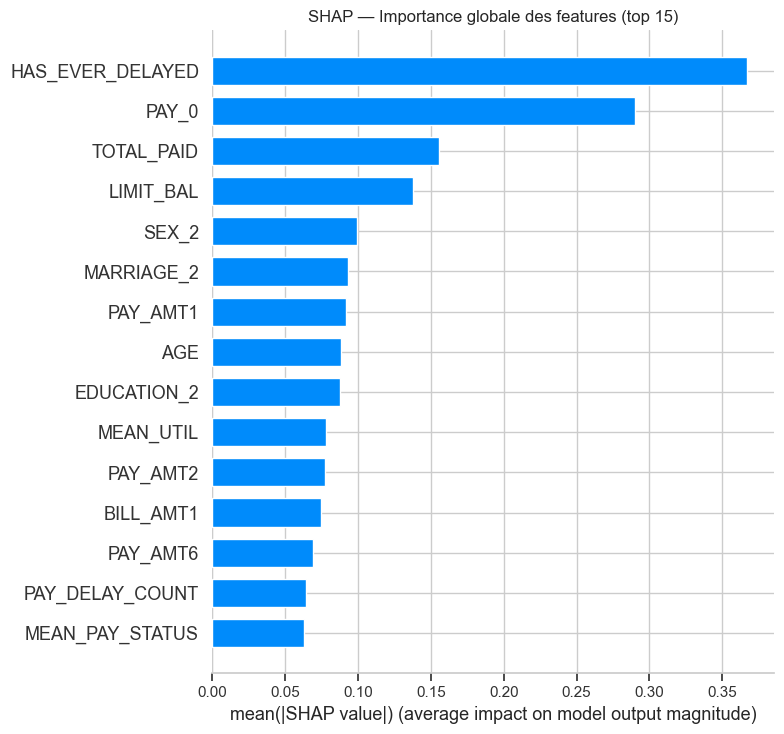

In [14]:
# Summary plot — top features (global)
plt.figure(figsize=(8, 10))
shap.summary_plot(shap_values, X_transformed_df, plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Importance globale des features (top 15)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '22_shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

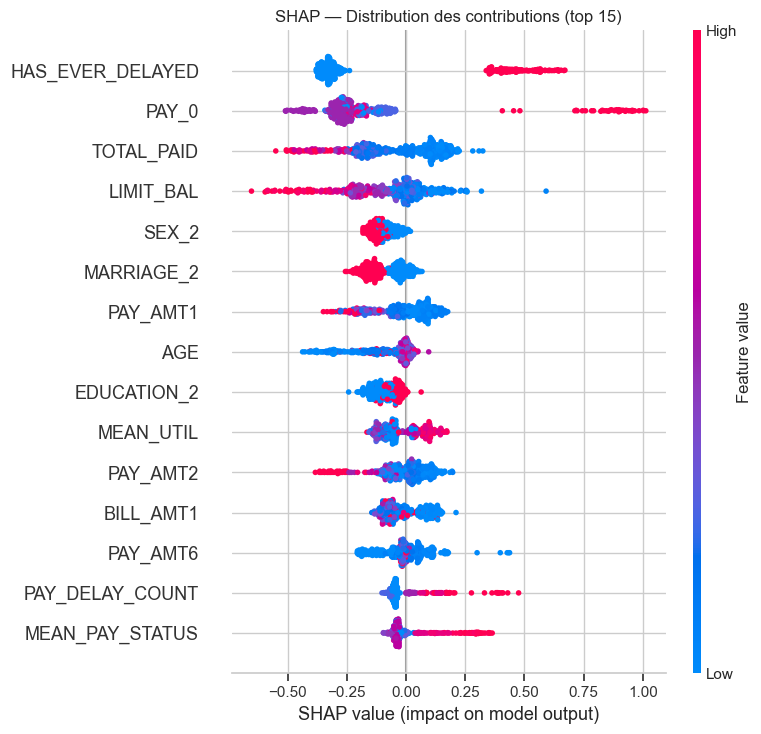

In [15]:
# Beeswarm plot — distribution des contributions
plt.figure(figsize=(8, 10))
shap.summary_plot(shap_values, X_transformed_df, show=False, max_display=15)
plt.title('SHAP — Distribution des contributions (top 15)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '22_shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()

**Lecture du beeswarm :**
- L'axe X = contribution SHAP (positive = pousse vers "défaut")
- La couleur = valeur de la feature (rouge = élevée, bleu = basse)
- Pour `PAY_DELAY_COUNT` : valeurs élevées (rouge) → SHAP très positif
  → le modèle apprend bien que "beaucoup de retards = défaut"

### 9.B — Explication locale : un client spécifique

In [16]:
# Choisir un client prédit "défaut" avec haute confiance
y_pred_proba = clf.predict_proba(X_transformed)[:, 1]
high_conf_default_idx = np.argmax(y_pred_proba)

print(f'Client #{high_conf_default_idx} (au sein de l échantillon SHAP)')
print(f'Probabilité de défaut prédite : {y_pred_proba[high_conf_default_idx]:.3f}')
print(f'Vraie classe                  : {y_sample.iloc[high_conf_default_idx]}')
print()
print('Top 5 features du client :')
print(X_sample.iloc[high_conf_default_idx][[
    'PAY_DELAY_COUNT', 'MAX_DELAY', 'PAY_0', 'LIMIT_BAL', 'MEAN_PAY_STATUS'
]].to_string())

Client #237 (au sein de l échantillon SHAP)
Probabilité de défaut prédite : 0.897
Vraie classe                  : 1

Top 5 features du client :
PAY_DELAY_COUNT        6.0
MAX_DELAY              2.0
PAY_0                  2.0
LIMIT_BAL          20000.0
MEAN_PAY_STATUS        2.0


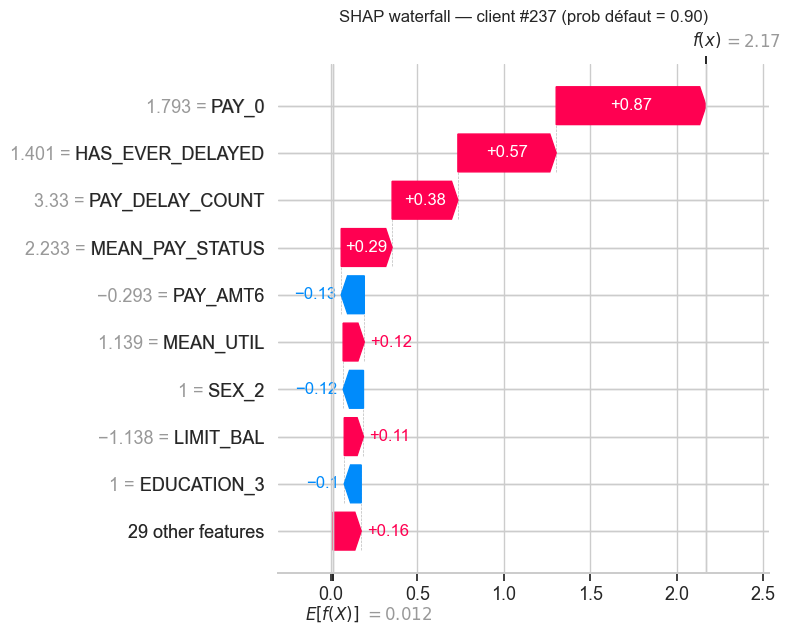

In [17]:
# Waterfall plot — décomposition pour CE client
plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_conf_default_idx],
        base_values=explainer.expected_value,
        data=X_transformed_df.iloc[high_conf_default_idx],
        feature_names=feature_names,
    ),
    max_display=10,
    show=False,
)
plt.title(f'SHAP waterfall — client #{high_conf_default_idx} (prob défaut = {y_pred_proba[high_conf_default_idx]:.2f})')
plt.tight_layout()
plt.savefig(FIG_DIR / '22_shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()

**Lecture du waterfall :**
- Point de départ : `E[f(X)]` = prédiction moyenne du modèle (log-odds)
- Chaque barre = contribution d'une feature pour CE client
- Rouge = pousse vers "défaut", bleu = pousse vers "non-défaut"
- Final : `f(x)` = log-odds prédites pour ce client

C'est cette explication qu'on pourra renvoyer côté API/Streamlit pour
**justifier la décision** auprès du conseiller bancaire.

## 10. 📌 Synthèse

### Modèle retenu : XGBoost
- `test_business_gain` = 0.484 (best)
- `recall` = 75.6% — capture 75% des défauts
- `seuil de décision` = 0.28 (optimisé pour minimiser le coût métier)
- Hyperparamètres : `n_estimators=200, max_depth=3, learning_rate=0.1`

### Top 3 features (SHAP)
Les features dérivées dominent — confirmation que le feature engineering
a apporté de la valeur réelle au modèle, pas seulement à la corrélation
linéaire :
1. `PAY_DELAY_COUNT` (notre feature)
2. `PAY_0` (originale, mois le plus récent)
3. `MEAN_PAY_STATUS` (notre feature)

### Artefacts produits
- `models/best_model.joblib` — pipeline complet pour la prod
- `models/metadata.json` — seuil, version, métriques
- Tous les runs sont dans MLflow → http://localhost:5050
- Figures dans `docs/figures/20_*` et `22_*`

### Prochaine étape
→ Étape 5 : créer l'API FastAPI qui charge `best_model.joblib`,
applique le préprocessing aux inputs, et retourne la probabilité de
défaut (+ classe via le seuil optimisé).